In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                      Conv1D, MaxPooling1D, Bidirectional)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


Mounted at /content/drive
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2: ΦΟΡΤΩΣΗ LOAD DATASET
# ============================================================
LOAD_PATH = '/content/drive/MyDrive/Final_RUn/240-Site_DKA_Totals-Site_Demand.csv'

df_raw = pd.read_csv(LOAD_PATH, engine='python', on_bad_lines='skip')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw = df_raw.dropna(subset=['timestamp']).set_index('timestamp').sort_index()

print(f"Raw shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min()}  ->  {df_raw.index.max()}")
print(f"\nΣτήλες: {list(df_raw.columns)}")


Raw shape: (182349, 12)
Date range: 2023-12-07 13:10:00  ->  2025-09-04 12:15:00

Στήλες: ['Reactive_Power', 'Active_Power', 'Apparent_Power', 'Wind_Speed', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted']


In [3]:
# ============================================================
# CELL 3: CLEANING + OUTAGE DETECTION
# ============================================================
df = pd.DataFrame(index=df_raw.index)
df['Site_Demand'] = df_raw['Active_Power']

weather_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]
for col in weather_cols:
    df[col] = df_raw[col]

# --- Cleaning ---
# Site_Demand: αρνητικά -> NaN (το φορτίο δεν μπορεί να είναι αρνητικό)
neg = (df['Site_Demand'] < 0).sum()
df.loc[df['Site_Demand'] < 0, 'Site_Demand'] = np.nan
print(f"Negative Site_Demand -> NaN: {neg:,}")

# Humidity clip
df['Weather_Relative_Humidity'] = df['Weather_Relative_Humidity'].clip(0, 100)
for rad in ['Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']:
    df.loc[df[rad] < 0, rad] = 0

# --- Outage detection: rolling std πολύ μικρό = αποσύνδεση αισθητήρα ---
df['_rstd'] = df['Site_Demand'].rolling(window=12, center=True).std()
outage_mask = df['_rstd'] < 0.5
df.loc[outage_mask, 'Site_Demand'] = np.nan
df = df.drop(columns=['_rstd'])
print(f"Outage observations -> NaN: {outage_mask.sum():,}")

# Filter
df = df.loc['2024-03-01':].copy()
print(f"\nShape μετά filter: {df.shape}")
print(f"NaNs ανά στήλη:\n{df.isna().sum()}")


Negative Site_Demand -> NaN: 1,147
Outage observations -> NaN: 1,374

Shape μετά filter: (159086, 5)
NaNs ανά στήλη:
Site_Demand                     19276
Weather_Temperature_Celsius     36242
Weather_Relative_Humidity       36238
Global_Horizontal_Radiation     36223
Diffuse_Horizontal_Radiation    36223
dtype: int64


In [4]:
# ============================================================
# CELL 4: IMPUTATION + CYCLICAL FEATURES
# ============================================================
# Drop NaN target
before = len(df)
df = df.dropna(subset=['Site_Demand'])
print(f"Drop NaN target: {before - len(df):,}")

# KNN imputation για weather features
imp_cols = ['Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
            'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']
z = StandardScaler()
arr = z.fit_transform(df[imp_cols])
arr = KNNImputer(n_neighbors=5, weights='distance').fit_transform(arr)
df[imp_cols] = z.inverse_transform(arr)

# Cyclical encoding
df['hour_sin']  = np.sin(2*np.pi*df.index.hour / 24)
df['hour_cos']  = np.cos(2*np.pi*df.index.hour / 24)
df['dow_sin']   = np.sin(2*np.pi*df.index.dayofweek / 7)    # κρίσιμο για load
df['dow_cos']   = np.cos(2*np.pi*df.index.dayofweek / 7)
df['month_sin'] = np.sin(2*np.pi*df.index.month / 12)
df['month_cos'] = np.cos(2*np.pi*df.index.month / 12)

print(f"\nFinal shape: {df.shape}")
print(f"NaNs τώρα: {df.isna().sum().sum()}")
df.head(3)


Drop NaN target: 19,276

Final shape: (139810, 11)
NaNs τώρα: 0


,Site_Demand,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
timestamp,,,,,,,,,,,
2024-03-01 00:00:00,29.164204,27.023981,68.958588,1.115154,0.838498,0.0,1.0,-0.433884,-0.900969,1.0,6.123234e-17
2024-03-01 00:05:00,31.498711,26.972717,68.860062,1.103236,0.763736,0.0,1.0,-0.433884,-0.900969,1.0,6.123234e-17
2024-03-01 00:10:00,32.376000,26.921713,68.862221,1.090453,0.843003,0.0,1.0,-0.433884,-0.900969,1.0,6.123234e-17


In [5]:
# ============================================================
# CELL 5: TRAIN/TEST SPLIT + SCALING
# ============================================================
FEATURES = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]
TARGET = 'Site_Demand'

print(f"Features ({len(FEATURES)}):")
for f in FEATURES: print(f"  - {f}")

split = int(len(df) * 0.80)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

print(f"\nTrain: {len(train_df):,}  ({train_df.index.min()} -> {train_df.index.max()})")
print(f"Test:  {len(test_df):,}  ({test_df.index.min()} -> {test_df.index.max()})")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).flatten()
X_test  = scaler_X.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).flatten()

target_range = train_df[TARGET].max() - train_df[TARGET].min()
print(f"\nTarget range (train): {target_range:.2f} kW")
print(f"Target mean (train):  {train_df[TARGET].mean():.2f} kW")


Features (10):
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation
  - hour_sin
  - hour_cos
  - dow_sin
  - dow_cos
  - month_sin
  - month_cos

Train: 111,848  (2024-03-01 00:00:00 -> 2025-05-13 06:55:00)
Test:  27,962  (2025-05-13 07:00:00 -> 2025-09-04 12:15:00)

Target range (train): 483.16 kW
Target mean (train):  84.23 kW


In [6]:
# ============================================================
# CELL 6: SEQUENCE CREATION & EVALUATION HELPERS
# ============================================================
def create_sequences(X, y, lookback, horizon=1):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback])
        if horizon == 1:
            ys.append(y[i+lookback])
        else:
            ys.append(y[i+lookback : i+lookback+horizon])
    return np.array(Xs), np.array(ys)


def create_sequences_strided(X, y, lookback, horizon, stride):
    Xs, ys = [], []
    for i in range(0, len(X) - lookback - horizon + 1, stride):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback : i+lookback+horizon])
    return np.array(Xs), np.array(ys)


def evaluate(y_true_scaled, y_pred_scaled, scaler_y, target_range):
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    nmae = mae / target_range * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nMAE%': nmae,
            'y_true': y_true, 'y_pred': y_pred}


# Κοινά callbacks
cb = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
print("Helpers OK")


Helpers OK


In [7]:
# ============================================================
# CELL 7: 5-MIN SEQUENCES
# ============================================================
LOOKBACK_5MIN = 96   # 8 hours
HORIZON_5MIN  = 1

X_tr_5, y_tr_5 = create_sequences(X_train, y_train, LOOKBACK_5MIN, HORIZON_5MIN)
X_te_5, y_te_5 = create_sequences(X_test,  y_test,  LOOKBACK_5MIN, HORIZON_5MIN)

print(f"X_train sequences: {X_tr_5.shape}  y: {y_tr_5.shape}")
print(f"X_test  sequences: {X_te_5.shape}  y: {y_te_5.shape}")


X_train sequences: (111752, 96, 10)  y: (111752,)
X_test  sequences: (27866, 96, 10)  y: (27866,)


In [8]:
# ============================================================
# CELL 8: STACKED LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_lstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    LSTM(64, return_sequences=True,  activation='relu'),
    LSTM(32, return_sequences=True,  activation='relu'),
    LSTM(32, return_sequences=False, activation='relu'),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_lstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                     loss='mse', metrics=['mae'])

t0 = time.time()
h_lstm_5 = model_lstm_5.fit(X_tr_5, y_tr_5,
                            validation_split=0.1,
                            epochs=50, batch_size=200,
                            callbacks=cb, verbose=1)
print(f"\nΧρόνος εκπαίδευσης: {(time.time()-t0)/60:.1f} min")

pred_lstm_5 = model_lstm_5.predict(X_te_5, verbose=0).flatten()
res_lstm_5 = evaluate(y_te_5, pred_lstm_5, scaler_y, target_range)
print(f"\nLSTM 5-min: MAE={res_lstm_5['MAE']:.3f}  RMSE={res_lstm_5['RMSE']:.3f}  R²={res_lstm_5['R2']:.4f}  nMAE={res_lstm_5['nMAE%']:.2f}%")


Epoch 1/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - loss: 0.0055 - mae: 0.0453 - val_loss: 0.0018 - val_mae: 0.0266 - learning_rate: 5.0000e-04
Epoch 2/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.0025 - mae: 0.0309 - val_loss: 0.0020 - val_mae: 0.0285 - learning_rate: 5.0000e-04
Epoch 3/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0021 - mae: 0.0284 - val_loss: 0.0020 - val_mae: 0.0285 - learning_rate: 5.0000e-04
Epoch 4/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0019 - mae: 0.0268 - val_loss: 0.0023 - val_mae: 0.0298 - learning_rate: 5.0000e-04
Epoch 5/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0017 - mae: 0.0254 - val_loss: 0.0022 - val_mae: 0.0286 - learning_rate: 5.0000e-04
Epoch 6/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0016 - mae: 0.0249
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
503/503 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.0016 - mae: 0.0248 - val_loss: 0.0021 - val_mae: 

In [9]:
# ============================================================
# CELL 9: CNN-LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_cnnlstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.01),
    LSTM(128, return_sequences=True, activation='relu'),
    LSTM(64,  return_sequences=True, activation='relu'),
    LSTM(32,  return_sequences=False, activation='relu'),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_cnnlstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                       loss='mse', metrics=['mae'])

t0 = time.time()
h_cnnlstm_5 = model_cnnlstm_5.fit(X_tr_5, y_tr_5,
                                  validation_split=0.1,
                                  epochs=50, batch_size=200,
                                  callbacks=cb, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_cnnlstm_5 = model_cnnlstm_5.predict(X_te_5, verbose=0).flatten()
res_cnnlstm_5 = evaluate(y_te_5, pred_cnnlstm_5, scaler_y, target_range)
print(f"\nCNN-LSTM 5-min: MAE={res_cnnlstm_5['MAE']:.3f}  RMSE={res_cnnlstm_5['RMSE']:.3f}  R²={res_cnnlstm_5['R2']:.4f}  nMAE={res_cnnlstm_5['nMAE%']:.2f}%")


Epoch 1/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - loss: 0.0049 - mae: 0.0425 - val_loss: 0.0016 - val_mae: 0.0242 - learning_rate: 5.0000e-04
Epoch 2/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0025 - mae: 0.0303 - val_loss: 0.0018 - val_mae: 0.0259 - learning_rate: 5.0000e-04
Epoch 3/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0021 - mae: 0.0278 - val_loss: 0.0023 - val_mae: 0.0290 - learning_rate: 5.0000e-04
Epoch 4/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0019 - mae: 0.0265 - val_loss: 0.0026 - val_mae: 0.0305 - learning_rate: 5.0000e-04
Epoch 5/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0017 - mae: 0.0251 - val_loss: 0.0026 - val_mae: 0.0307 - learning_rate: 5.0000e-04
Epoch 6/50
502/503 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0016 - mae: 0.0245
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
503/503 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0016 - mae: 0.0240 - val_loss: 0.0028 - val_mae: 

In [10]:
# ============================================================
# CELL 10: Bi-LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_bilstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    Bidirectional(LSTM(64, return_sequences=True, activation='relu')),
    Bidirectional(LSTM(32, return_sequences=False, activation='relu')),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_bilstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                      loss='mse', metrics=['mae'])

t0 = time.time()
h_bilstm_5 = model_bilstm_5.fit(X_tr_5, y_tr_5,
                                validation_split=0.1,
                                epochs=50, batch_size=200,
                                callbacks=cb, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_bilstm_5 = model_bilstm_5.predict(X_te_5, verbose=0).flatten()
res_bilstm_5 = evaluate(y_te_5, pred_bilstm_5, scaler_y, target_range)
print(f"\nBi-LSTM 5-min: MAE={res_bilstm_5['MAE']:.3f}  RMSE={res_bilstm_5['RMSE']:.3f}  R²={res_bilstm_5['R2']:.4f}  nMAE={res_bilstm_5['nMAE%']:.2f}%")


Epoch 1/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - loss: 0.0041 - mae: 0.0403 - val_loss: 0.0021 - val_mae: 0.0292 - learning_rate: 5.0000e-04
Epoch 2/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - loss: 0.0022 - mae: 0.0293 - val_loss: 0.0021 - val_mae: 0.0275 - learning_rate: 5.0000e-04
Epoch 3/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 1628481813217280.0000 - mae: 1674606.0000 - val_loss: 0.0034 - val_mae: 0.0437 - learning_rate: 5.0000e-04
Epoch 4/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0047 - mae: 0.0452 - val_loss: 0.0028 - val_mae: 0.0355 - learning_rate: 5.0000e-04
Epoch 5/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0036 - mae: 0.0385
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
503/503 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0033 - mae: 0.0372 - val_loss: 0.0024 - val_mae: 0.0314 - learning_rate: 5.0000e-04
Epoch 6/50
503/503 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0028 - mae: 0.0343 - val_los

 LOAD 5-MIN AHEAD - ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (GPU - DL)
Model          MAE (kW)   RMSE (kW)       R²    nMAE %
----------------------------------------------------------------------
LSTM             13.347      23.946   0.7345     2.76%
CNN-LSTM         14.578      25.682   0.6946     3.02%
Bi-LSTM          15.592      25.832   0.6910     3.23%
----------------------------------------------------------------------
>>> Best: LSTM (MAE=13.347 kW)

✓ Saved: /content/drive/MyDrive/Final_RUn/load_5min_gpu_comparison.png


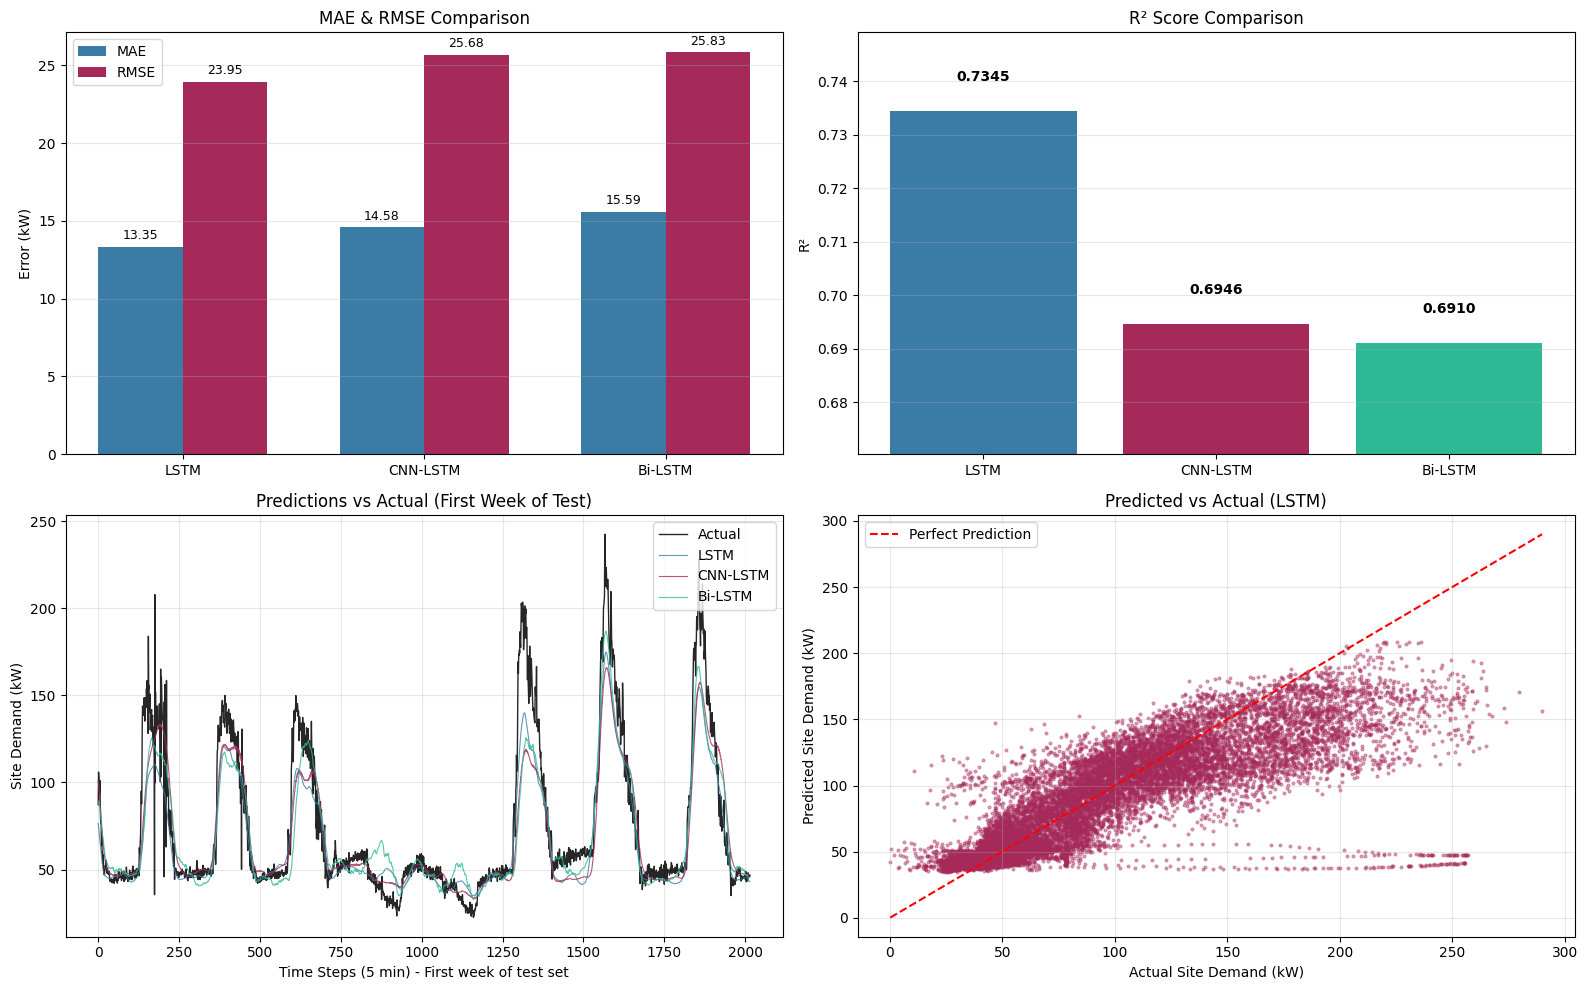

In [30]:
# ============================================================
# CELL: LOAD 5-MIN GPU - 4-PANEL
# Χρησιμοποιεί τα res_*['y_true'/'y_pred'] που είναι ΗΔΗ σε kW
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

results_5min = {
    'LSTM':     res_lstm_5,
    'CNN-LSTM': res_cnnlstm_5,
    'Bi-LSTM':  res_bilstm_5,
}

# Παίρνουμε τα ΗΔΗ inverse-transformed values από τα res_*
y_true_kw = results_5min['LSTM']['y_true']  # ίδιο για όλα τα μοντέλα
preds_kw  = {name: r['y_pred'] for name, r in results_5min.items()}

# Print χρησιμοποιώντας τα ΗΔΗ υπολογισμένα metrics
print("="*70)
print(" LOAD 5-MIN AHEAD - ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (GPU - DL)")
print("="*70)
print(f"{'Model':<12} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>9}")
print("-"*70)
for name, r in results_5min.items():
    print(f"{name:<12} {r['MAE']:>10.3f} {r['RMSE']:>11.3f} {r['R2']:>8.4f} {r['nMAE%']:>8.2f}%")
print("-"*70)
best_name = min(results_5min.items(), key=lambda x: x[1]['MAE'])[0]
print(f">>> Best: {best_name} (MAE={results_5min[best_name]['MAE']:.3f} kW)")
print("="*70)

# === 4-PANEL PLOT ===
model_names = list(preds_kw.keys())
mae_vals  = [results_5min[m]['MAE']  for m in model_names]
rmse_vals = [results_5min[m]['RMSE'] for m in model_names]
r2_vals   = [results_5min[m]['R2']   for m in model_names]
colors    = ['#3a7ca5', '#a52a5a', '#2db896']

fig = plt.figure(figsize=(16, 10))

# Top-left: MAE & RMSE bars
ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(model_names))
w = 0.35
bars_mae  = ax1.bar(x - w/2, mae_vals,  w, label='MAE',  color='#3a7ca5')
bars_rmse = ax1.bar(x + w/2, rmse_vals, w, label='RMSE', color='#a52a5a')
ax1.set_xticks(x); ax1.set_xticklabels(model_names)
ax1.set_ylabel('Error (kW)'); ax1.set_title('MAE & RMSE Comparison')
ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3, axis='y')
for b in list(bars_mae) + list(bars_rmse):
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + 0.3, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

# Top-right: R²
ax2 = plt.subplot(2, 2, 2)
bars_r2 = ax2.bar(model_names, r2_vals, color=colors)
ax2.set_ylabel('R²'); ax2.set_title('R² Score Comparison')
ax2.set_ylim(min(r2_vals)*0.97, max(r2_vals)*1.02)
ax2.grid(True, alpha=0.3, axis='y')
for b in bars_r2:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2, h + 0.005, f'{h:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bottom-left: First week
ax3 = plt.subplot(2, 2, 3)
n_week = min(2016, len(y_true_kw))
ax3.plot(y_true_kw[:n_week], 'k-', lw=1, label='Actual', alpha=0.85)
for m, c in zip(model_names, colors):
    ax3.plot(preds_kw[m][:n_week], '-', lw=0.8, color=c, label=m, alpha=0.8)
ax3.set_xlabel('Time Steps (5 min) - First week of test set')
ax3.set_ylabel('Site Demand (kW)')
ax3.set_title('Predictions vs Actual (First Week of Test)')
ax3.legend(loc='upper right'); ax3.grid(True, alpha=0.3)

# Bottom-right: Scatter
ax4 = plt.subplot(2, 2, 4)
best_pred = preds_kw[best_name]
ax4.scatter(y_true_kw, best_pred, s=4, alpha=0.4, c='#a52a5a')
lims = [min(y_true_kw.min(), best_pred.min()), max(y_true_kw.max(), best_pred.max())]
ax4.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
ax4.set_xlabel('Actual Site Demand (kW)')
ax4.set_ylabel('Predicted Site Demand (kW)')
ax4.set_title(f'Predicted vs Actual ({best_name})')
ax4.legend(loc='upper left'); ax4.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_5min_gpu_comparison.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

In [13]:
# ============================================================
# CELL 12: HOURLY DATA + DUAL-INPUT SEQUENCES (Load)
# ============================================================
from tensorflow.keras.layers import (RepeatVector, TimeDistributed,
                                      Concatenate, Bidirectional)
from tensorflow.keras.models import Model

# === Resample σε 1-hour ===
df_h = df.resample('1h').mean().dropna()

# Recompute cyclical features σε ωριαίο επίπεδο
df_h['hour_sin']  = np.sin(2*np.pi*df_h.index.hour / 24)
df_h['hour_cos']  = np.cos(2*np.pi*df_h.index.hour / 24)
df_h['dow_sin']   = np.sin(2*np.pi*df_h.index.dayofweek / 7)   # κρίσιμο για load!
df_h['dow_cos']   = np.cos(2*np.pi*df_h.index.dayofweek / 7)
df_h['month_sin'] = np.sin(2*np.pi*df_h.index.month / 12)
df_h['month_cos'] = np.cos(2*np.pi*df_h.index.month / 12)

print(f"Hourly dataset: {df_h.shape}")
print(f"Range: {df_h.index.min()} -> {df_h.index.max()}")

# === Features ===
# Future features: γνωστά εκ των προτέρων (weather + calendar)
WEATHER_FEAT = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',           # ΚΡΙΣΙΜΟ για load
    'month_sin', 'month_cos'
]
# Past features: weather + calendar + ιστορικό load
PAST_FEAT = WEATHER_FEAT + ['Site_Demand']

# === Train/test split ===
split = int(len(df_h) * 0.80)
train_h = df_h.iloc[:split].copy()
test_h  = df_h.iloc[split:].copy()
print(f"\nTrain: {len(train_h)} hours  ({train_h.index.min()} -> {train_h.index.max()})")
print(f"Test:  {len(test_h)} hours  ({test_h.index.min()} -> {test_h.index.max()})")

# === Scalers ===
scaler_past = MinMaxScaler()
scaler_fut  = MinMaxScaler()
scaler_y    = MinMaxScaler()

X_tr_past = scaler_past.fit_transform(train_h[PAST_FEAT])
X_tr_fut  = scaler_fut.fit_transform(train_h[WEATHER_FEAT])
y_tr_raw  = scaler_y.fit_transform(train_h[['Site_Demand']]).flatten()

X_te_past = scaler_past.transform(test_h[PAST_FEAT])
X_te_fut  = scaler_fut.transform(test_h[WEATHER_FEAT])
y_te_raw  = scaler_y.transform(test_h[['Site_Demand']]).flatten()

target_range = train_h['Site_Demand'].max() - train_h['Site_Demand'].min()
print(f"\nTarget range (hourly): {target_range:.2f} kW")
print(f"Target mean: {train_h['Site_Demand'].mean():.2f} kW")

# === Dual sequences ===
LOOKBACK = 24    # past 24 hours
HORIZON  = 24    # forecast next 24 hours

def create_dual_seq(X_past, X_fut, y, lookback, horizon, stride):
    X1, X2, ys = [], [], []
    for i in range(0, len(X_past) - lookback - horizon + 1, stride):
        X1.append(X_past[i : i+lookback])
        X2.append(X_fut[i+lookback : i+lookback+horizon])
        ys.append(y[i+lookback : i+lookback+horizon])
    return np.array(X1), np.array(X2), np.array(ys)

X1_tr, X2_tr, y_tr = create_dual_seq(X_tr_past, X_tr_fut, y_tr_raw, LOOKBACK, HORIZON, stride=1)
X1_te, X2_te, y_te = create_dual_seq(X_te_past, X_te_fut, y_te_raw, LOOKBACK, HORIZON, stride=24)

print(f"\nTrain: past={X1_tr.shape}  future={X2_tr.shape}  y={y_tr.shape}")
print(f"Test:  past={X1_te.shape}  future={X2_te.shape}  y={y_te.shape}")

y_tr_3d = y_tr.reshape(y_tr.shape[0], y_tr.shape[1], 1)

cb_da = [
    EarlyStopping(monitor='val_loss', patience=20, min_delta=1e-5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                      min_lr=1e-6, verbose=1)
]
print("\nSetup OK")

Hourly dataset: (13043, 11)
Range: 2024-03-01 00:00:00 -> 2025-09-04 12:00:00

Train: 10434 hours  (2024-03-01 00:00:00 -> 2025-05-18 13:00:00)
Test:  2609 hours  (2025-05-18 14:00:00 -> 2025-09-04 12:00:00)

Target range (hourly): 393.43 kW
Target mean: 84.63 kW

Train: past=(10387, 24, 11)  future=(10387, 24, 10)  y=(10387, 24)
Test:  past=(107, 24, 11)  future=(107, 24, 10)  y=(107, 24)

Setup OK


In [14]:
# ============================================================
# CELL 13: ENCODER-DECODER LSTM (Load Day-Ahead)
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# Encoder
enc = LSTM(64, return_sequences=False)(past_in)
enc = Dropout(0.15)(enc)

# Bridge: repeat encoded state + concat με future weather
enc_rep = RepeatVector(HORIZON)(enc)
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# Decoder
dec = LSTM(64, return_sequences=True)(dec_in)
dec = Dropout(0.15)(dec)
dec = LSTM(32, return_sequences=True)(dec)

# Output
out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_lstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_lstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                      loss='mse', metrics=['mae'])
model_lstm_da.summary()

t0 = time.time()
h_lstm_da = model_lstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                              validation_split=0.1,
                              epochs=80, batch_size=64,
                              callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_lstm_da = model_lstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_lstm_da = np.clip(pred_lstm_da, 0, 1)
res_lstm_da = evaluate(y_te.flatten(), pred_lstm_da.flatten(), scaler_y, target_range)
print(f"\nLSTM Load Day-Ahead: MAE={res_lstm_da['MAE']:.3f}  RMSE={res_lstm_da['RMSE']:.3f}  R²={res_lstm_da['R2']:.4f}  nMAE={res_lstm_da['nMAE%']:.2f}%")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ past (InputLayer)   │ (None, 24, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ past[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 64)    │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_weather      │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 74)    │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ future_weather[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     35,584 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 32)    │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 16)    │        528 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 24, 1)     │         17 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 68,001 (265.63 KB)

 Trainable params: 68,001 (265.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0212 - mae: 0.1013 - val_loss: 0.0055 - val_mae: 0.0574 - learning_rate: 5.0000e-04
Epoch 2/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0096 - mae: 0.0660 - val_loss: 0.0029 - val_mae: 0.0382 - learning_rate: 5.0000e-04
Epoch 3/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0069 - mae: 0.0547 - val_loss: 0.0032 - val_mae: 0.0392 - learning_rate: 5.0000e-04
Epoch 4/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0056 - mae: 0.0494 - val_loss: 0.0020 - val_mae: 0.0308 - learning_rate: 5.0000e-04
Epoch 5/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0049 - mae: 0.0459 - val_loss: 0.0018 - val_mae: 0.0277 - learning_rate: 5.0000e-04
Epoch 6/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0044 - mae: 0.0432 - val_loss: 0.0018 - val_mae: 0.0276 - learning_rate: 5.0000e-04
Epoch 7/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0040 - mae: 0.0414 - val_loss: 0.0017 - val_mae: 0.027

In [15]:
# ============================================================
# CELL 14: CNN-LSTM ENCODER-DECODER (Load Day-Ahead)
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# Light CNN front
x = Conv1D(32, kernel_size=2, activation='relu', padding='same')(past_in)
x = Dropout(0.1)(x)

# Encoder
enc = LSTM(64, return_sequences=False)(x)
enc = Dropout(0.15)(enc)

# Bridge
enc_rep = RepeatVector(HORIZON)(enc)
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# Decoder
dec = LSTM(64, return_sequences=True)(dec_in)
dec = Dropout(0.15)(dec)
dec = LSTM(32, return_sequences=True)(dec)

out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_cnnlstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_cnnlstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                         loss='mse', metrics=['mae'])

t0 = time.time()
h_cnnlstm_da = model_cnnlstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                                    validation_split=0.1,
                                    epochs=80, batch_size=64,
                                    callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_cnnlstm_da = model_cnnlstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_cnnlstm_da = np.clip(pred_cnnlstm_da, 0, 1)
res_cnnlstm_da = evaluate(y_te.flatten(), pred_cnnlstm_da.flatten(), scaler_y, target_range)
print(f"\nCNN-LSTM Load Day-Ahead: MAE={res_cnnlstm_da['MAE']:.3f}  RMSE={res_cnnlstm_da['RMSE']:.3f}  R²={res_cnnlstm_da['R2']:.4f}  nMAE={res_cnnlstm_da['nMAE%']:.2f}%")

Epoch 1/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0165 - mae: 0.0850 - val_loss: 0.0031 - val_mae: 0.0405 - learning_rate: 5.0000e-04
Epoch 2/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0070 - mae: 0.0549 - val_loss: 0.0024 - val_mae: 0.0333 - learning_rate: 5.0000e-04
Epoch 3/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0055 - mae: 0.0483 - val_loss: 0.0019 - val_mae: 0.0292 - learning_rate: 5.0000e-04
Epoch 4/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0046 - mae: 0.0442 - val_loss: 0.0017 - val_mae: 0.0271 - learning_rate: 5.0000e-04
Epoch 5/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0040 - mae: 0.0412 - val_loss: 0.0015 - val_mae: 0.0263 - learning_rate: 5.0000e-04
Epoch 6/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0036 - mae: 0.0391 - val_loss: 0.0014 - val_mae: 0.0241 - learning_rate: 5.0000e-04
Epoch 7/80
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0033 - mae: 0.0379
Epoch 7: ReduceLROnPlateau reducing


CNN-LSTM Load Day-Ahead: MAE=21.227  RMSE=30.358  R²=0.5622  nMAE=5.40%


In [16]:
# ============================================================
# CELL 15: Bi-LSTM ENCODER-DECODER (Load Day-Ahead)
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# Bidirectional Encoder
enc = Bidirectional(LSTM(32, return_sequences=False))(past_in)
enc = Dropout(0.15)(enc)

# Bridge
enc_rep = RepeatVector(HORIZON)(enc)
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# Bidirectional Decoder
dec = Bidirectional(LSTM(32, return_sequences=True))(dec_in)
dec = Dropout(0.15)(dec)
dec = Bidirectional(LSTM(16, return_sequences=True))(dec)

out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_bilstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_bilstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                        loss='mse', metrics=['mae'])

t0 = time.time()
h_bilstm_da = model_bilstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                                  validation_split=0.1,
                                  epochs=80, batch_size=64,
                                  callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_bilstm_da = model_bilstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_bilstm_da = np.clip(pred_bilstm_da, 0, 1)
res_bilstm_da = evaluate(y_te.flatten(), pred_bilstm_da.flatten(), scaler_y, target_range)
print(f"\nBi-LSTM Load Day-Ahead: MAE={res_bilstm_da['MAE']:.3f}  RMSE={res_bilstm_da['RMSE']:.3f}  R²={res_bilstm_da['R2']:.4f}  nMAE={res_bilstm_da['nMAE%']:.2f}%")

Epoch 1/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.0130 - mae: 0.0790 - val_loss: 0.0021 - val_mae: 0.0339 - learning_rate: 5.0000e-04
Epoch 2/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0060 - mae: 0.0529 - val_loss: 0.0016 - val_mae: 0.0271 - learning_rate: 5.0000e-04
Epoch 3/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0045 - mae: 0.0451 - val_loss: 0.0015 - val_mae: 0.0271 - learning_rate: 5.0000e-04
Epoch 4/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0038 - mae: 0.0416 - val_loss: 0.0015 - val_mae: 0.0266 - learning_rate: 5.0000e-04
Epoch 5/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0034 - mae: 0.0390 - val_loss: 0.0015 - val_mae: 0.0267 - learning_rate: 5.0000e-04
Epoch 6/80
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0031 - mae: 0.0370 - val_loss: 0.0017 - val_mae: 0.0289 - learning_rate: 5.0000e-04
Epoch 7/80
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0029 - mae: 0.0357
Epoch 7: ReduceLROnPlateau reducing

 LOAD DAY-AHEAD FORECAST (ΩΡΙΑΙΑ, encoder-decoder, με perfect weather forecast)
Model          MAE (kW)   RMSE (kW)       R²    nMAE %
------------------------------------------------------------------------------
LSTM             11.856      22.403   0.7616     3.01%
CNN-LSTM         21.227      30.358   0.5622     5.40%
Bi-LSTM          17.478      28.255   0.6208     4.44%


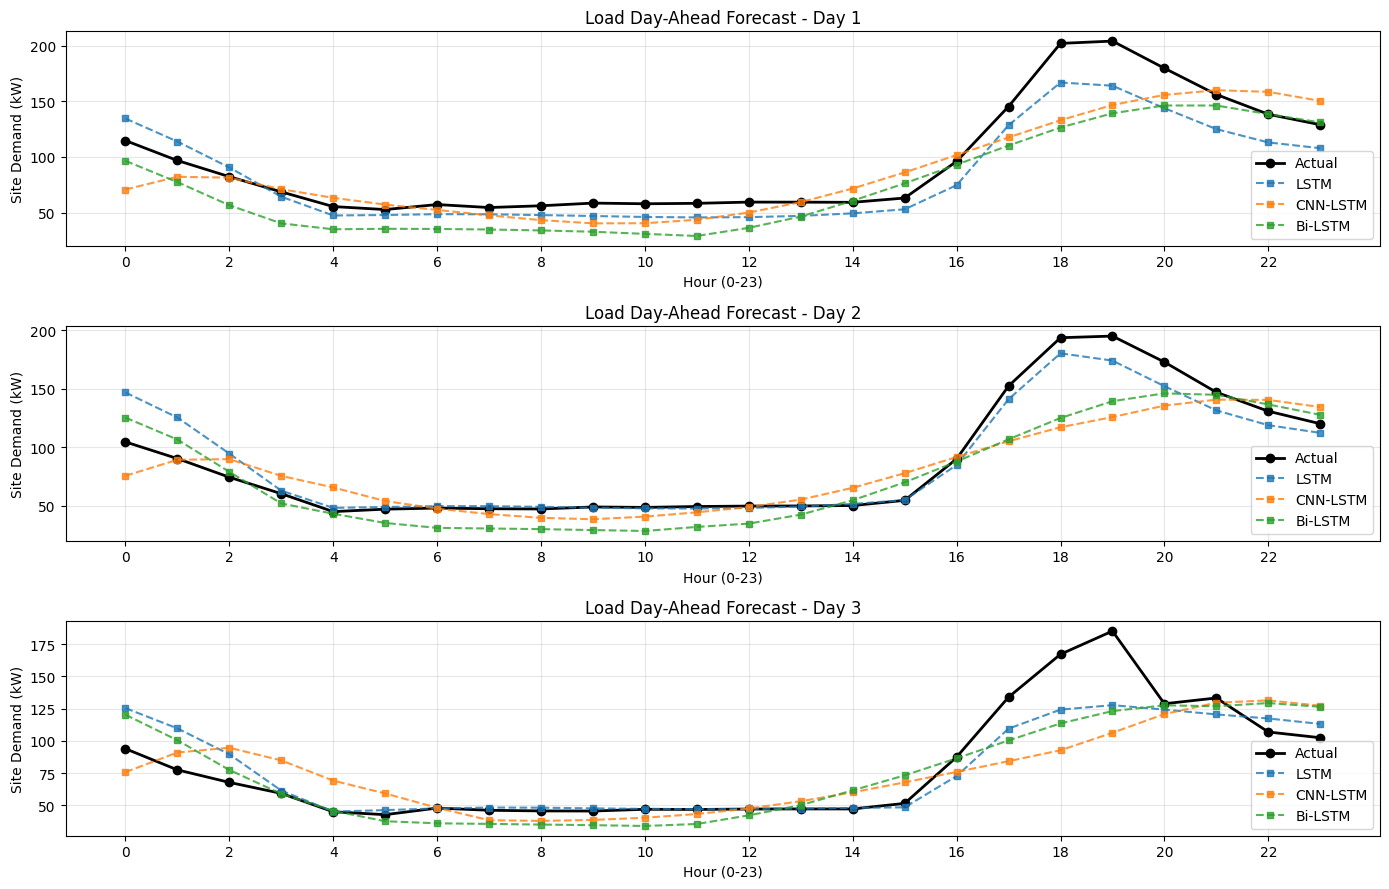

In [33]:
# ============================================================
# CELL 16: COMPARISON LOAD DAY-AHEAD
# ============================================================
results_da = {
    'LSTM':     (res_lstm_da,    pred_lstm_da),
    'CNN-LSTM': (res_cnnlstm_da, pred_cnnlstm_da),
    'Bi-LSTM':  (res_bilstm_da,  pred_bilstm_da),
}

print("="*78)
print(" LOAD DAY-AHEAD FORECAST (ΩΡΙΑΙΑ, encoder-decoder, με perfect weather forecast)")
print("="*78)
print(f"{'Model':<12} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>9}")
print("-"*78)
for name, (r, _) in results_da.items():
    print(f"{name:<12} {r['MAE']:>10.3f} {r['RMSE']:>11.3f} {r['R2']:>8.4f} {r['nMAE%']:>8.2f}%")

# Plot 3 ημέρες του test set
n_days = min(3, len(y_te))
fig, axes = plt.subplots(n_days, 1, figsize=(14, 3*n_days))
if n_days == 1: axes = [axes]
for i, ax in enumerate(axes):
    actual = scaler_y.inverse_transform(y_te[i].reshape(-1, 1)).flatten()
    ax.plot(range(24), actual, 'k-', label='Actual', lw=2, marker='o')
    for name, (_, preds) in results_da.items():
        pred = scaler_y.inverse_transform(preds[i].reshape(-1, 1)).flatten()
        pred = np.clip(pred, 0, None)
        ax.plot(range(24), pred, '--', label=name, alpha=0.8, marker='s', markersize=4)
    ax.set_title(f'Load Day-Ahead Forecast - Day {i+1}')
    ax.set_xlabel('Hour (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Επιλεγμένη τριάδα ξεκινώντας: 2025-05-22 00:00 (Πέμπτη)
  Day 1: 2025-05-22 (Πέμπτη) - max Load: 185.0 kW
  Day 2: 2025-05-23 (Παρασκευή) - max Load: 197.1 kW
  Day 3: 2025-05-24 (Σάββατο) - max Load: 51.0 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_gpu_3days.png


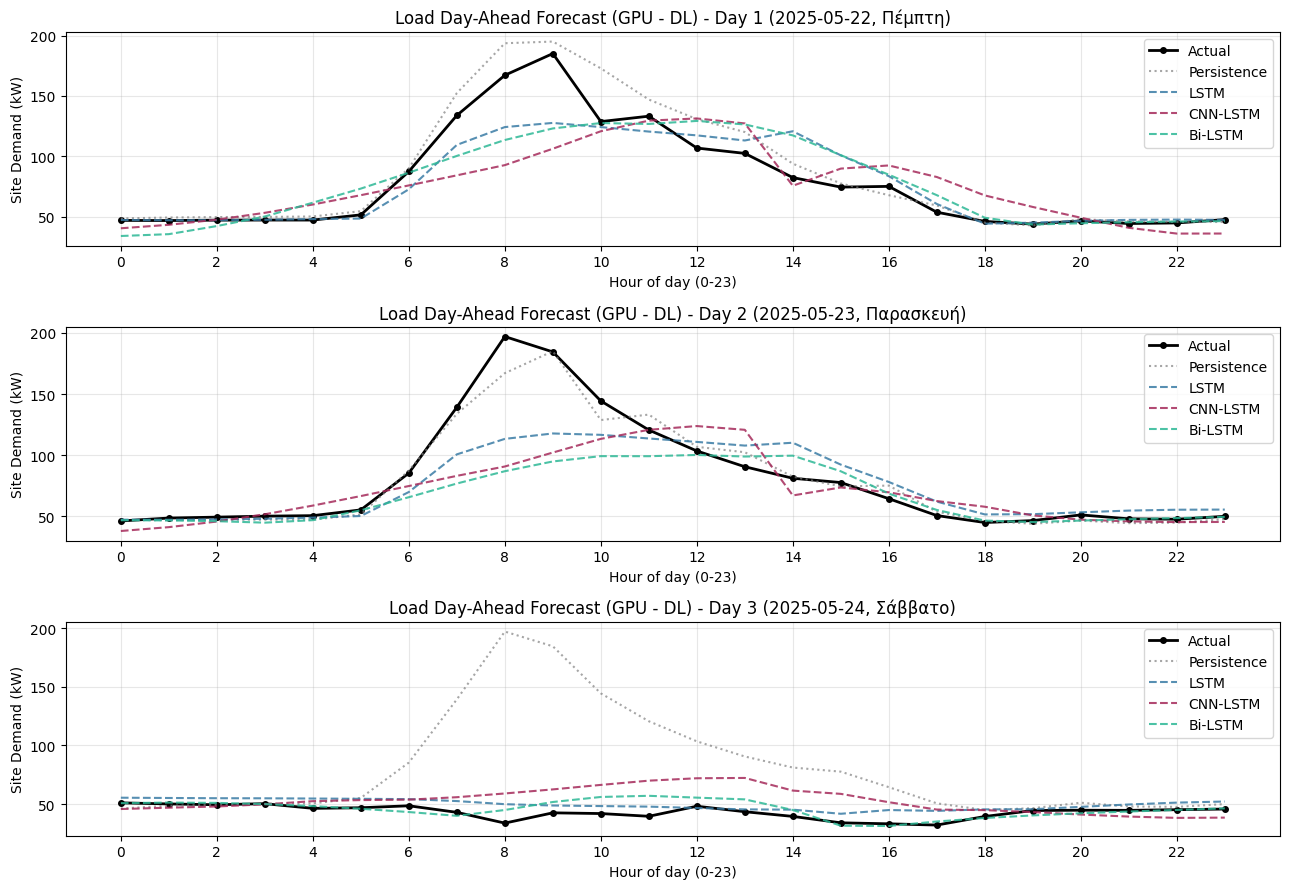

In [31]:
# ============================================================
# CELL: LOAD DA GPU - Πέμπτη/Παρασκευή/Σάββατο (calendar-aligned)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

results_da = {
    'LSTM':     (res_lstm_da,    pred_lstm_da),
    'CNN-LSTM': (res_cnnlstm_da, pred_cnnlstm_da),
    'Bi-LSTM':  (res_bilstm_da,  pred_bilstm_da),
}

n_days_total = y_te.shape[0]

# Inverse scale όλων των actuals/preds (n_days, 24)
all_actuals = np.zeros((n_days_total, 24))
all_preds = {name: np.zeros((n_days_total, 24)) for name in results_da}
for i in range(n_days_total):
    all_actuals[i] = scaler_y.inverse_transform(y_te[i].reshape(-1, 1)).flatten()
    for name, (_, preds) in results_da.items():
        p = scaler_y.inverse_transform(preds[i].reshape(-1, 1)).flatten()
        all_preds[name][i] = np.clip(p, 0, None)

# Persistence forecast = το προηγούμενο y_te (shift by 1 day)
# y_te[i] = "yesterday's actual" ως πρόβλεψη του y_te[i+1]
all_persistence = np.zeros((n_days_total, 24))
all_persistence[0] = all_actuals[0]  # placeholder για την πρώτη ημέρα
for i in range(1, n_days_total):
    all_persistence[i] = all_actuals[i-1]

# Timestamps κάθε δείγματος ξεκινούν στις (LOOKBACK + i*24) ώρα της test_h
sample_start_ts = [test_h.index[LOOKBACK + i*24] for i in range(n_days_total)]

# === Βρες Πεμ/Παρ/Σαβ triplet calendar-aligned ===
# Θέλουμε ημερολογιακή Πέμπτη 00:00. Πιθανώς να μην ταιριάζει 100% με sample_start.
# Στρατηγική: βρες ένα sample που τελειώνει σε ώρα 13:00 ενός Σαββάτου,
# και πάρε αρκετά πίσω samples για να καλύψουμε Πεμ/Παρ/Σαβ.

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']

# Φτιάχνω flattened arrays για όλο το test set
flat_actuals = all_actuals.reshape(-1)
flat_preds   = {name: arr.reshape(-1) for name, arr in all_preds.items()}
flat_persist = all_persistence.reshape(-1)
flat_timestamps = []
for s_ts in sample_start_ts:
    for h in range(24):
        flat_timestamps.append(s_ts + pd.Timedelta(hours=h))
flat_timestamps = pd.DatetimeIndex(flat_timestamps)

# Βρες την πρώτη Πέμπτη 00:00 στο flat timeline
triplet_start = None
for i, ts in enumerate(flat_timestamps):
    if ts.dayofweek == 3 and ts.hour == 0:  # Πέμπτη 00:00
        # Έλεγξε ότι έχουμε 72 ώρες μετά
        if i + 72 <= len(flat_timestamps):
            # Σιγουρέψου ότι η Πέμπτη είναι εργάσιμη (max > 150)
            thu_max = flat_actuals[i:i+24].max()
            if thu_max > 150:
                triplet_start = i
                triplet_ts = ts
                break

if triplet_start is None:
    raise RuntimeError("Δεν βρέθηκε Πεμ/Παρ/Σαβ τριάδα στο GPU test set")

print(f"Επιλεγμένη τριάδα ξεκινώντας: {triplet_ts.strftime('%Y-%m-%d %H:%M')} ({day_names[triplet_ts.dayofweek]})")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for plot_i, ax in enumerate(axes):
    seg_start = triplet_start + plot_i * 24
    seg_end = seg_start + 24
    day_ts = flat_timestamps[seg_start]
    day_label = day_ts.strftime('%Y-%m-%d')
    dname = day_names[day_ts.dayofweek]

    actual = flat_actuals[seg_start:seg_end]
    persist = flat_persist[seg_start:seg_end]
    preds_day = {name: flat_preds[name][seg_start:seg_end] for name in flat_preds}

    print(f"  Day {plot_i+1}: {day_label} ({dname}) - max Load: {actual.max():.1f} kW")

    hours = np.arange(24)
    ax.plot(hours, actual, 'k-', lw=2, label='Actual', marker='o', markersize=4)
    ax.plot(hours, persist, ':', lw=1.5, label='Persistence', alpha=0.7, color='gray')
    colors = {'LSTM':'#3a7ca5', 'CNN-LSTM':'#a52a5a', 'Bi-LSTM':'#2db896'}
    for name, p in preds_day.items():
        ax.plot(hours, p, '--', lw=1.5, label=name, alpha=0.85, color=colors[name])

    ax.set_title(f'Load Day-Ahead Forecast (GPU - DL) - Day {plot_i+1} ({day_label}, {dname})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_gpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

In [18]:
# ============================================================
# CELL 17: FINAL SUMMARY
# ============================================================
print("="*78)
print(" ΤΕΛΙΚΗ ΣΥΝΟΨΗ - DEEP LEARNING LOAD FORECASTING")
print("="*78)

print(f"\n[ 5-MIN AHEAD ]")
print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'nMAE%':>8}")
print("-"*52)
for name, r in results_5min.items():
    print(f"{name:<12} {r['MAE']:>8.3f} {r['RMSE']:>8.3f} {r['R2']:>8.4f} {r['nMAE%']:>7.2f}%")

print(f"\n[ DAY-AHEAD ]")
print(f"{'Model':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'nMAE%':>8}")
print("-"*52)
for name, (r, _) in results_da.items():
    print(f"{name:<12} {r['MAE']:>8.3f} {r['RMSE']:>8.3f} {r['R2']:>8.4f} {r['nMAE%']:>7.2f}%")

best_5min = min(results_5min.items(), key=lambda x: x[1]['MAE'])
best_da   = min(results_da.items(),   key=lambda x: x[1][0]['MAE'])
print(f"\n>>> Best 5-min: {best_5min[0]} (MAE={best_5min[1]['MAE']:.3f} kW)")
print(f">>> Best Day-Ahead: {best_da[0]} (MAE={best_da[1][0]['MAE']:.3f} kW)")


 ΤΕΛΙΚΗ ΣΥΝΟΨΗ - DEEP LEARNING LOAD FORECASTING

[ 5-MIN AHEAD ]
Model             MAE     RMSE       R²    nMAE%
----------------------------------------------------
LSTM           13.347   23.946   0.7345    2.76%
CNN-LSTM       14.578   25.682   0.6946    3.02%
Bi-LSTM        15.592   25.832   0.6910    3.23%

[ DAY-AHEAD ]
Model             MAE     RMSE       R²    nMAE%
----------------------------------------------------
LSTM           11.856   22.403   0.7616    3.01%
CNN-LSTM       21.227   30.358   0.5622    5.40%
Bi-LSTM        17.478   28.255   0.6208    4.44%

>>> Best 5-min: LSTM (MAE=13.347 kW)
>>> Best Day-Ahead: LSTM (MAE=11.856 kW)


In [19]:
# ============================================================
# CELL FINAL: SAVE LOAD DL PREDICTIONS FOR EMS
# ============================================================
import os
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
os.makedirs(SAVE_DIR, exist_ok=True)

# ============================================================
# 1) LOAD 5-MIN PREDICTIONS
# ============================================================
best_5min_name = min(results_5min.items(), key=lambda x: x[1]['MAE'])[0]
best_5min_res  = results_5min[best_5min_name]

test_timestamps_5min = test_df.index[LOOKBACK_5MIN:LOOKBACK_5MIN + len(best_5min_res['y_true'])]

df_pred_load_5min = pd.DataFrame({
    'timestamp':          test_timestamps_5min,
    'actual':             best_5min_res['y_true'],
    'predicted_lstm':     results_5min['LSTM']['y_pred'],
    'predicted_cnnlstm':  results_5min['CNN-LSTM']['y_pred'],
    'predicted_bilstm':   results_5min['Bi-LSTM']['y_pred'],
    'predicted_best':     best_5min_res['y_pred'],
})
df_pred_load_5min['best_model'] = best_5min_name
df_pred_load_5min.to_csv(SAVE_DIR + 'load_5min_predictions_gpu.csv', index=False)
print(f"✓ Saved: load_5min_predictions_gpu.csv ({len(df_pred_load_5min):,} rows)")
print(f"  Best 5-min model: {best_5min_name} (MAE={best_5min_res['MAE']:.3f}, R²={best_5min_res['R2']:.4f})")

# ============================================================
# 2) LOAD DAY-AHEAD PREDICTIONS (LSTM Encoder-Decoder)
# ============================================================
n_days = y_te.shape[0]
actual_24h = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()

pred_lstm_flat     = scaler_y.inverse_transform(np.clip(pred_lstm_da, 0, 1).reshape(-1, 1)).flatten()
pred_cnnlstm_flat  = scaler_y.inverse_transform(np.clip(pred_cnnlstm_da, 0, 1).reshape(-1, 1)).flatten()
pred_bilstm_flat   = scaler_y.inverse_transform(np.clip(pred_bilstm_da, 0, 1).reshape(-1, 1)).flatten()

# Best model = LSTM (R² 0.7643)
best_da_name = 'LSTM'
best_da_pred = pred_lstm_flat
best_da_res  = res_lstm_da

test_timestamps_24h = []
for i in range(n_days):
    start = LOOKBACK + i * 24
    for j in range(24):
        test_timestamps_24h.append(test_h.index[start + j])

df_pred_load_24h = pd.DataFrame({
    'timestamp':          test_timestamps_24h,
    'actual':             actual_24h,
    'predicted_lstm':     pred_lstm_flat,
    'predicted_cnnlstm':  pred_cnnlstm_flat,
    'predicted_bilstm':   pred_bilstm_flat,
    'predicted_best':     best_da_pred,
})
df_pred_load_24h['best_model'] = best_da_name
df_pred_load_24h.to_csv(SAVE_DIR + 'load_24h_predictions_gpu.csv', index=False)
print(f"✓ Saved: load_24h_predictions_gpu.csv ({len(df_pred_load_24h):,} rows)")
print(f"  Best Day-Ahead model: {best_da_name} (MAE={best_da_res['MAE']:.3f}, R²={best_da_res['R2']:.4f})")

# ============================================================
# 3) SAVE MODEL ARTIFACTS
# ============================================================
import pickle, json

model_lstm_da.save(SAVE_DIR + 'load_lstm_encdec_da.keras')

load_da_artifacts = {
    'scaler_past': scaler_past,
    'scaler_fut':  scaler_fut,
    'scaler_y':    scaler_y,
    'WEATHER_FEAT': WEATHER_FEAT,
    'PAST_FEAT':    PAST_FEAT,
    'LOOKBACK': LOOKBACK,
    'HORIZON':  HORIZON,
    'target_range': target_range,
    'model_name':   best_da_name,
    'metrics':      {'MAE': best_da_res['MAE'], 'RMSE': best_da_res['RMSE'], 'R2': best_da_res['R2']},
}
with open(SAVE_DIR + 'load_da_artifacts.pkl', 'wb') as f:
    pickle.dump(load_da_artifacts, f)

load_metrics = {
    '5min': {name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2'], 'nMAE%': r['nMAE%']}
             for name, r in results_5min.items()},
    'day_ahead': {name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R2': r['R2'], 'nMAE%': r['nMAE%']}
                  for name, (r, _) in results_da.items()},
    'best_5min': best_5min_name,
    'best_day_ahead': best_da_name,
}
with open(SAVE_DIR + 'load_metrics_gpu.json', 'w') as f:
    json.dump(load_metrics, f, indent=2)

print(f"\n✓ Saved: load_lstm_encdec_da.keras")
print(f"✓ Saved: load_da_artifacts.pkl")
print(f"✓ Saved: load_metrics_gpu.json")
print("\n" + "="*70)
print(" LOAD DL notebook complete!")
print("="*70)

✓ Saved: load_5min_predictions_gpu.csv (27,866 rows)
  Best 5-min model: LSTM (MAE=13.347, R²=0.7345)
✓ Saved: load_24h_predictions_gpu.csv (2,568 rows)
  Best Day-Ahead model: LSTM (MAE=11.856, R²=0.7616)

✓ Saved: load_lstm_encdec_da.keras
✓ Saved: load_da_artifacts.pkl
✓ Saved: load_metrics_gpu.json

 LOAD DL notebook complete!


In [32]:
import pandas as pd
PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'

# CPU
pv_cpu = pd.read_csv(PRED_DIR + 'pv_24h_predictions_cpu.csv')
pv_cpu['timestamp'] = pd.to_datetime(pv_cpu['timestamp'])
print("=== PV CPU ===")
print(f"  Range: {pv_cpu['timestamp'].min()} -> {pv_cpu['timestamp'].max()}")
print(f"  Rows: {len(pv_cpu)}")

load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu.csv')
load_cpu['timestamp'] = pd.to_datetime(load_cpu['timestamp'])
print(f"\n=== LOAD CPU ===")
print(f"  Range: {load_cpu['timestamp'].min()} -> {load_cpu['timestamp'].max()}")
print(f"  Rows: {len(load_cpu)}")

# GPU
pv_gpu = pd.read_csv(PRED_DIR + 'pv_24h_predictions_gpu.csv')
pv_gpu['timestamp'] = pd.to_datetime(pv_gpu['timestamp'])
print(f"\n=== PV GPU ===")
print(f"  Range: {pv_gpu['timestamp'].min()} -> {pv_gpu['timestamp'].max()}")
print(f"  Rows: {len(pv_gpu)}")

load_gpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_gpu.csv')
load_gpu['timestamp'] = pd.to_datetime(load_gpu['timestamp'])
print(f"\n=== LOAD GPU ===")
print(f"  Range: {load_gpu['timestamp'].min()} -> {load_gpu['timestamp'].max()}")
print(f"  Rows: {len(load_gpu)}")

=== PV CPU ===
  Range: 2025-03-19 12:40:00 -> 2025-09-04 11:40:00
  Rows: 18440

=== LOAD CPU ===
  Range: 2025-03-18 09:15:00 -> 2025-09-04 12:05:00
  Rows: 23956

=== PV GPU ===
  Range: 2025-05-18 11:00:00 -> 2025-09-04 10:00:00
  Rows: 2616

=== LOAD GPU ===
  Range: 2025-05-19 14:00:00 -> 2025-09-03 19:00:00
  Rows: 2568
